In [1]:
import pandas as pd
import psycopg2
import getpass

# Te pedirá la contraseña de forma segura al ejecutar (no se guarda en el notebook)
db_password = getpass.getpass("Ingresa tu contraseña de PostgreSQL: ")

conn = psycopg2.connect(
    host="localhost",
    database="olist_store",
    user="postgres",
    password=db_password,
    port=5432
)

print("✅ Conexión exitosa a PostgreSQL")

Ingresa tu contraseña de PostgreSQL:  ········


✅ Conexión exitosa a PostgreSQL


In [4]:
# Pregunta 1: ¿Cuáles son las categorías con más ingresos?

query_q1 = """
SELECT 
    p.product_category_name AS categoria,
    COUNT(oi.order_item_id) AS num_ventas,
    SUM(oi.price) AS ingresos_totales,
    ROUND(AVG(oi.price), 2) AS precio_promedio
FROM products p
INNER JOIN order_items oi
  ON p.product_id = oi.product_id
GROUP BY p.product_category_name
ORDER BY ingresos_totales DESC
LIMIT 15
"""

# Traer datos en un DataFrame
df_q1 = pd.read_sql(query_q1, conn)

# Ver los datos
print(df_q1)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16260\557978914.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query_q1, conn)


                 categoria  num_ventas  ingresos_totales  precio_promedio
0             beleza_saude        9670        1258681.34           130.16
1       relogios_presentes        5991        1205005.68           201.14
2          cama_mesa_banho       11115        1036988.68            93.30
3            esporte_lazer        8641         988048.97           114.34
4   informatica_acessorios        7827         911954.32           116.51
5         moveis_decoracao        8334         729762.49            87.56
6               cool_stuff        3796         635290.85           167.36
7    utilidades_domesticas        6964         632248.66            90.79
8               automotivo        4235         592720.11           139.96
9       ferramentas_jardim        4347         485256.46           111.63
10              brinquedos        4117         483946.60           117.55
11                   bebes        3065         411764.89           134.34
12              perfumaria        3419

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16260\2526288400.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q1,


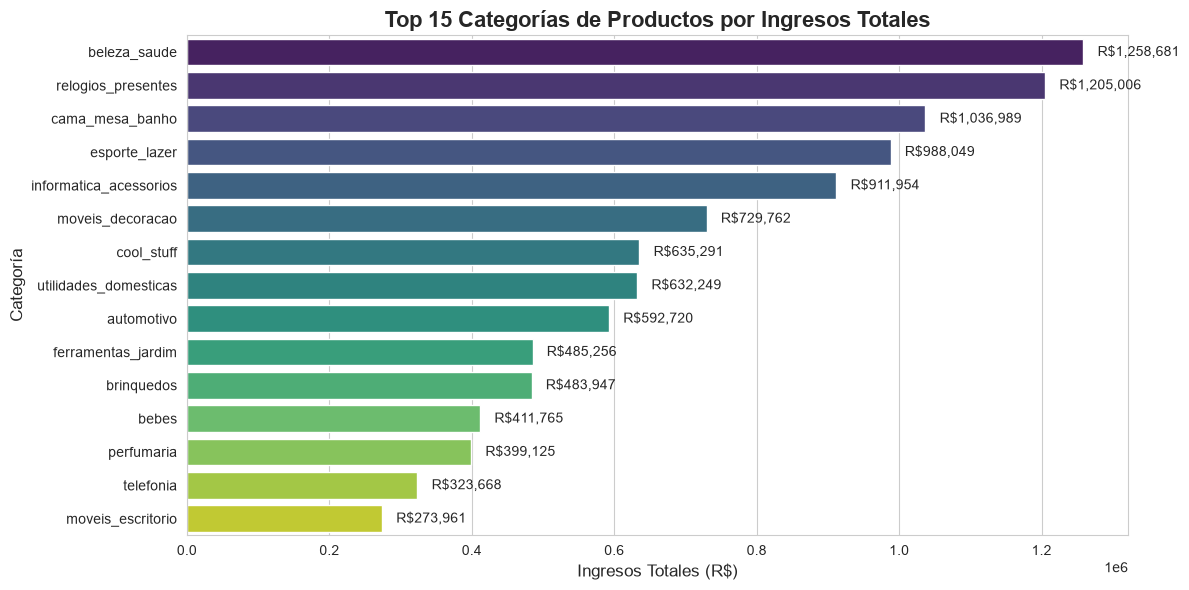

✅ Gráfica guardada en visualizations/01_categorias_ingresos.png


<Figure size 1200x600 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Crear la figura
plt.figure(figsize=(12, 6))

# Crear gráfica de barras
sns.barplot(data=df_q1, 
            x='ingresos_totales', 
            y='categoria', 
            palette='viridis')

# Personalizar la gráfica
plt.title('Top 15 Categorías de Productos por Ingresos Totales', fontsize=16, fontweight='bold')
plt.xlabel('Ingresos Totales (R$)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Mostrar valores en las barras
for i, v in enumerate(df_q1['ingresos_totales']):
    plt.text(v + 20000, i, f'R${v:,.0f}', va='center')

plt.tight_layout()
plt.show()

# Guardar la imagen
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
print("✅ Gráfica guardada en visualizations/01_categorias_ingresos.png")

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16260\2415220524.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1_en = pd.read_sql(query_q1_english, conn)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16260\2415220524.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_q1_en,


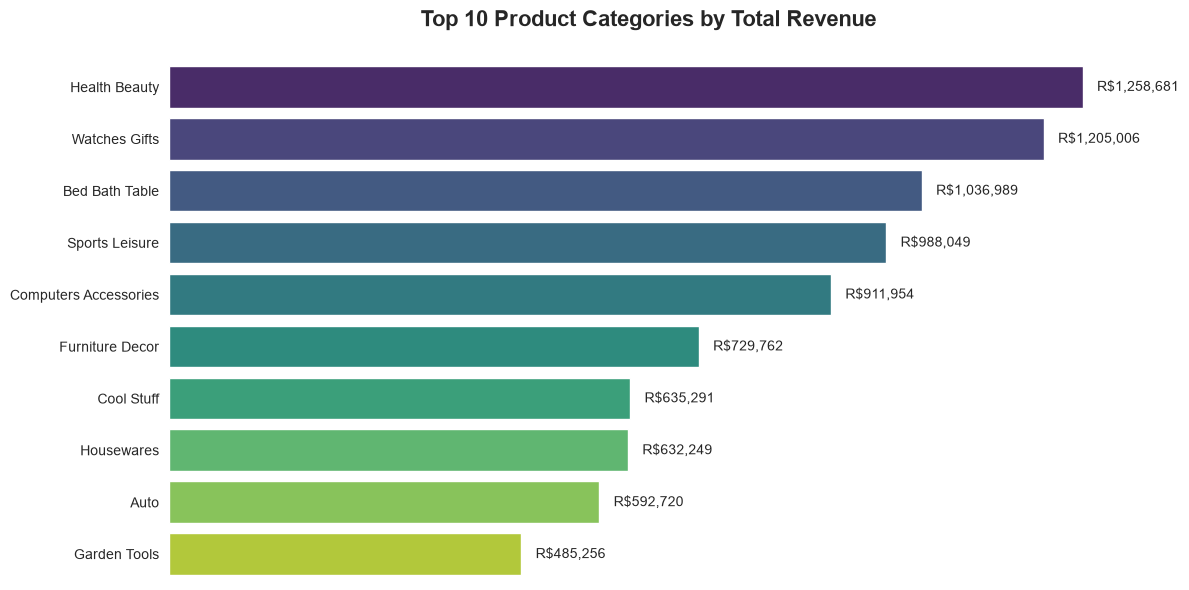

✅ Gráfica actualizada y guardada


<Figure size 1200x600 with 0 Axes>

✅ Gráfica actualizada y guardada


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

query_q1_english = """
SELECT 
    COALESCE(t.product_category_name_english, p.product_category_name) AS categoria,
    COUNT(oi.order_item_id) AS num_ventas,
    SUM(oi.price) AS ingresos_totales,
    ROUND(AVG(oi.price), 2) AS precio_promedio
FROM products p
INNER JOIN order_items oi
  ON p.product_id = oi.product_id
LEFT JOIN product_category_name_translation t
  ON p.product_category_name = t.product_category_name
GROUP BY COALESCE(t.product_category_name_english, p.product_category_name)
ORDER BY ingresos_totales DESC
LIMIT 10
"""

df_q1_en = pd.read_sql(query_q1_english, conn)
df_q1_en['categoria'] = df_q1_en['categoria'].str.replace('_', ' ').str.title()

sns.set_style("white")
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_q1_en, 
                  x='ingresos_totales', 
                  y='categoria', 
                  palette='viridis')

ax.set_ylabel('')
plt.title('Top 10 Product Categories by Total Revenue', 
          fontsize=16, fontweight='bold', pad=25)

# Quitar el eje X completo (números y etiqueta)
ax.set_xlabel('')
ax.set_xticks([])

ax.grid(False)
sns.despine(left=True, bottom=True)

for i, v in enumerate(df_q1_en['ingresos_totales']):
    plt.text(v + 20000, i, f'R${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica actualizada y guardada")

plt.tight_layout()
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica actualizada y guardada")